Inspecting data and 

In [1]:
# import function
%load_ext autoreload
%autoreload 2
from functions import read_file, out_csv, summarise_dataframe
import pandas as pd

yaml_path= "../config.yaml"
inp_data_section='clean_data'
file_name1= 'clean'    
    

#importing data file:
Bdf= read_file(yaml_path, inp_data_section, file_name1) 

print('========================')
summarise_dataframe(Bdf)


Shape: (1069, 11)

--- Null counts ---
rating      181
synopsis     57
pages        14
dtype: int64

--- Dtypes ---
book_name          str
book_url           str
source_list        str
author             str
rating         float64
synopsis           str
pages          float64
pub_date           str
genres             str
img_url            str
data_source        str
dtype: object


In [2]:
Bdf.nunique()

book_name      1013
book_url       1069
source_list      15
author          696
rating          136
synopsis       1009
pages           492
pub_date        808
genres          695
img_url         987
data_source       2
dtype: int64

In [3]:
Bdf[Bdf['book_name'].duplicated(keep=False)]

,book_name,book_url,source_list,author,rating,synopsis,pages,pub_date,genres,img_url,data_source
1,Pride and Prejudice,https://www.goodreads.com/book/show/1885.Pride...,Best Books Ever,Jane Austen,4.30,This comedy of manners about the games of Eros...,279.0,1813-01-28,Classics|Romance|Fiction|Historical Fiction|Hi...,https://m.media-amazon.com/images/S/compressed...,GoodReads
2,To Kill a Mockingbird,https://www.goodreads.com/book/show/2657.To_Ki...,Best Books Ever,Harper Lee,4.26,"""Shoot all the bluejays you want, if you can h...",323.0,1960-07-11,Classics|Fiction|Historical Fiction|School|Lit...,https://m.media-amazon.com/images/S/compressed...,GoodReads
3,Harry Potter and the Order of the Phoenix,https://www.goodreads.com/book/show/2.Harry_Po...,Best Books Ever,J.K. Rowling,4.50,"The fifth book in the beloved, bestselling Har...",576.0,2003-06-21,Fantasy|Fiction|Young Adult|Harry Potter|Magic...,https://m.media-amazon.com/images/S/compressed...,GoodReads
9,The Picture of Dorian Gray,https://www.goodreads.com/book/show/5297.The_P...,Best Books Ever,Oscar Wilde,4.13,"In this celebrated work, his only novel, Wilde...",272.0,1890-07-01,Classics|Fiction|Horror|Gothic|Fantasy|Literat...,https://m.media-amazon.com/images/S/compressed...,GoodReads
10,Wuthering Heights,https://www.goodreads.com/book/show/6185.Wuthe...,Best Books Ever,Emily Brontë,3.89,You can find the redesigned cover of this edit...,464.0,1847-11-24,Classics|Fiction|Romance|Gothic|Historical Fic...,https://m.media-amazon.com/images/S/compressed...,GoodReads
...,...,...,...,...,...,...,...,...,...,...,...
1050,"The Lion, the Witch and the Wardrobe",http://books.google.de/books?id=mxKYtAEACAAJ&d...,Best Epic Fantasy,Clive Staples Lewis,4.13,New abridged version with full col. illus. for...,48.0,1998,Adventure stories,../app/missingcover.png,google_books
1058,War and Peace,http://books.google.de/books?id=UU1gAAAAMAAJ&d...,Best Historical Fiction,graf Leo Tolstoy,4.24,NaN,1538.0,1968,Historical fiction,http://books.google.com/books/content?id=UU1gA...,google_books
1062,The Shadow of the Wind,http://books.google.de/books?id=AWBQzwEACAAJ&d...,Best Historical Fiction,Carlos Ruiz Zafón,4.31,Beautiful illustrated edition of this runaway ...,0.0,2005-10-13,Fiction,http://books.google.com/books/content?id=AWBQz...,google_books
1063,A Tale of Two Cities,http://books.google.de/books?id=95ZpuQAACAAJ&d...,Best Historical Fiction,Charles Dickens,3.88,Set amid the terror of revolutionary Paris and...,701.0,1999,Executions and executioners,../app/missingcover.png,google_books


In [4]:
# 1. Ensure pub_date is in datetime format for accurate sorting
Bdf['pub_date'] = pd.to_datetime(Bdf['pub_date'], errors='coerce')

# 2. Count how many non-null values each row has across all columns
# (Higher score = more complete information)
Bdf['completeness_score'] = Bdf.notna().sum(axis=1)

# 3. Sort by completeness (highest first), then by pub_date (newest first)
# This guarantees that a complete row always beats an incomplete row.
Bdf = Bdf.sort_values(
    by=['completeness_score', 'pub_date'], 
    ascending=[False, False]
)

# 4. Keep the best row for each book name
books = Bdf.drop_duplicates(subset='book_name', keep='first')

# 5. Clean up by dropping the temporary scoring column
books = books.drop(columns=['completeness_score'])
print(books[books['book_name'].duplicated(keep=False)])

Empty DataFrame
Columns: [book_name, book_url, source_list, author, rating, synopsis, pages, pub_date, genres, img_url, data_source]
Index: []


In [5]:
summarise_dataframe(books)

Shape: (1013, 11)

--- Null counts ---
rating      177
synopsis     54
pages        12
pub_date    235
dtype: int64

--- Dtypes ---
book_name                 str
book_url                  str
source_list               str
author                    str
rating                float64
synopsis                  str
pages                 float64
pub_date       datetime64[us]
genres                    str
img_url                   str
data_source               str
dtype: object


In [6]:
books.nunique()

book_name      1013
book_url       1013
source_list      15
author          685
rating          136
synopsis        957
pages           478
pub_date        687
genres          680
img_url         937
data_source       2
dtype: int64

In [7]:
list_map = {
    'Best Books Ever': 'Best books Ever',
    'Best Epic Fantasy': 'Best Epic Fantasy',
    'The Best Epic Fantasy (fiction)': 'Best Epic Fantasy',
    'Books That Should Be Made Into Movies': 'Books that should be Movies',
    'Best Dystopian and Post-Apocalyptic Fiction': 'Best Dystopian and Post-Apocalyptic Fiction',
    'Best Book Boyfriends': 'Best Book cheesy romance',
    'Best Young Adult Books': 'Young Adult Books',
    'Books You Should Read': 'Books MUST Read',
    'Best Historical Fiction': 'Best Historical Fiction',
    'Books That Everyone Should Read At Least Once': 'Books MUST Read',
    'Books That Should Be Movies': 'Books that should be Movies',
    'Young Adult': 'Young Adult Books',
    'Best Books of the 20th Century': 'Best Books 20th Century',
    '20th Century Literature': 'Literature 20th Century',
    'Best Books of the Decade: 2000s': 'Best Books 21st Century' 
}

#.replace() to safely leave unmapped values alone
books['source_list'] = books['source_list'].replace(list_map)
books.source_list.unique()

<ArrowStringArray>
[                            'Best books Ever',
                           'Best Epic Fantasy',
                 'Books that should be Movies',
 'Best Dystopian and Post-Apocalyptic Fiction',
                    'Best Book cheesy romance',
                           'Young Adult Books',
                             'Books MUST Read',
                     'Best Historical Fiction',
                     'Best Books 21st Century',
                     'Best Books 20th Century',
                     'Literature 20th Century']
Length: 11, dtype: str

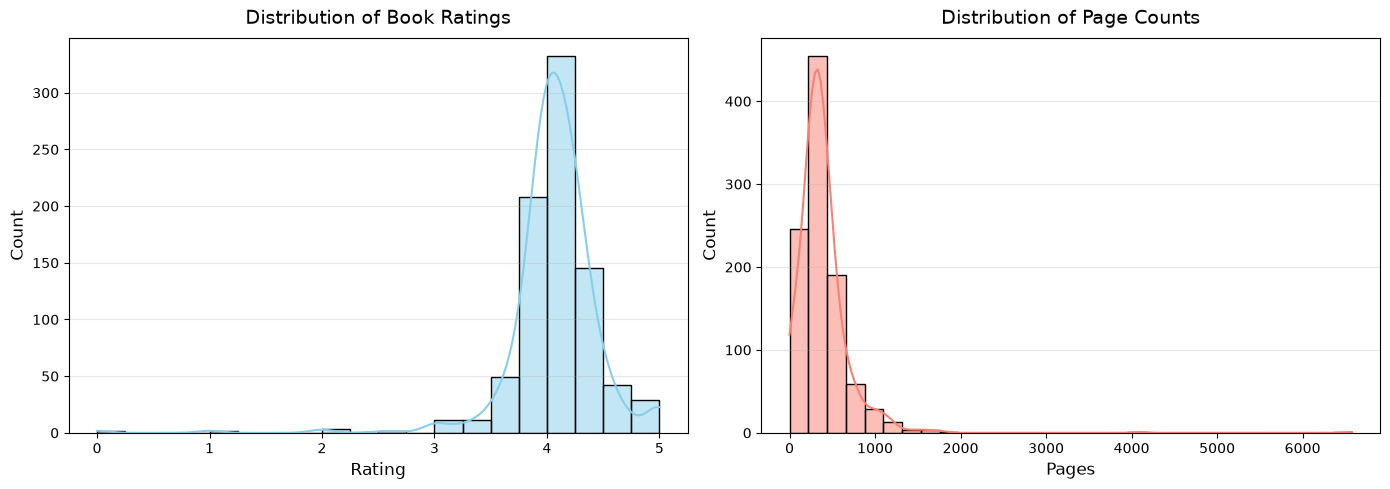

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
#ploting histograms for numeric columns
fig, axes = plt.subplots(1,2, figsize=(14,5))

#left plot
sns.histplot(
    data=books,
    x='rating',
    bins=20,
    kde=True,
    ax=axes[0],
    color='skyblue')
axes[0].set_title('Distribution of Book Ratings', fontsize=14, pad=10)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3) #subtle horizontal gridlines

# Right Plot: Pages Histogram 
sns.histplot(
    data=books, 
    x='pages', 
    bins=30,           # More bins because pages have a wider span (478 unique values)
    kde=True, 
    ax=axes[1], 
    color='salmon'
)
axes[1].set_title('Distribution of Page Counts', fontsize=14, pad=10)
axes[1].set_xlabel('Pages', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()


In [9]:
books[books.pages>1500]

,book_name,book_url,source_list,author,rating,synopsis,pages,pub_date,genres,img_url,data_source
357,The Mortal Instruments Boxed Set: City of Bone...,https://www.goodreads.com/book/show/6485421-th...,Best Book cheesy romance,Cassandra Clare,4.55,"In City of Bones, fifteen-year-old Clary Fray ...",1520.0,2009-10-27,Fantasy|Young Adult|Romance|Paranormal|Urban F...,https://m.media-amazon.com/images/S/compressed...,GoodReads
395,Harry Potter Series Box Set,https://www.goodreads.com/book/show/862041.Har...,Best Books 21st Century,J.K. Rowling,4.73,"Over 4000 pages of Harry Potter and his world,...",4100.0,2007-10-01,Fantasy|Young Adult|Fiction|Harry Potter|Magic...,https://m.media-amazon.com/images/S/compressed...,GoodReads
659,The Complete Aubrey/Maturin Novels,https://www.goodreads.com/book/show/24520.The_...,Best Historical Fiction,Patrick O'Brian,4.76,Patrick O’Brian’s twenty-one-volume Aubrey/Mat...,6576.0,1994-01-01,Historical Fiction|Fiction|Historical|Nautical...,https://m.media-amazon.com/images/S/compressed...,GoodReads
468,The Belgariad Boxed Set: Pawn of Prophecy / Qu...,https://www.goodreads.com/book/show/44660.The_...,Best Epic Fantasy,David Eddings,4.30,book 1 -- PAWN OF PROPHECY -- A fierce dispute...,1635.0,1984-01-01,Fantasy|Fiction|Epic Fantasy|High Fantasy|Scie...,https://m.media-amazon.com/images/S/compressed...,GoodReads
7,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,https://www.goodreads.com/book/show/30.J_R_R_T...,Best books Ever,J.R.R. Tolkien,4.62,These magical adaptations became instant class...,1728.0,1954-01-01,Fantasy|Fiction|Classics|Adventure|Science Fic...,https://m.media-amazon.com/images/S/compressed...,GoodReads
281,The Complete Sherlock Holmes,https://www.goodreads.com/book/show/188572.The...,Best Books 20th Century,Arthur Conan Doyle,4.51,A study in scarlet --The sign of four --Advent...,1796.0,1887-01-01,Classics|Mystery|Fiction|Crime|Short Stories|A...,https://m.media-amazon.com/images/S/compressed...,GoodReads
102,The Holy Bible: King James Version,https://www.goodreads.com/book/show/1923820.Th...,Books MUST Read,Anonymous,4.45,The King James Version is an Early Modern Engl...,1590.0,1611-01-01,Religion|Classics|Nonfiction|Christian|Philoso...,https://m.media-amazon.com/images/S/compressed...,GoodReads


In [10]:
# Keep only books with pages <= 2000
books = books.drop([357,395,659,468,7])
books.shape

(1008, 11)

In [11]:
#Genre frequency
books.genres.unique()

<ArrowStringArray>
[                                                                              'Fiction',
                                                                               'Fantasy',
                                                            'Fantasy|Historical Fiction',
                      'Fantasy|Romantasy|Romance|Fae|Fantasy Romance|Dark Romance|Magic',
                                                                      'Juvenile Fiction',
                'Thriller|Mystery|Audiobook|Fiction|Book Club|Mystery Thriller|Suspense',
 'Fantasy|Science Fiction Fantasy|Science Fiction|Post Apocalyptic|Adventure|Dark|Adult',
          'Fiction|Novels|Adventure|Ebooks|Science Fiction Fantasy|Fantasy|High Fantasy',
                    'Thriller|Mystery|Fiction|Audiobook|Mystery Thriller|Suspense|Crime',
                'Thriller|Mystery|Audiobook|Mystery Thriller|Fiction|Book Club|Suspense',
 ...
                                                                            

## Genre Cleaning + Feature Objects  
the raw `genres` column has 676 unique combinations across 1008 rows — too much noise and chaos. K-means on that menas curse of dimensionality = garbage clusters.  

**Plan:**  
1. Explode `genres` on `|`, normalize (lowercase + strip), count frequencies  
2. Collapse messy raw tags into a small set of canonical genres via keyword rules  
3. Multi-hot encode → one 0/1 column per canonical genre  
4. Build two DataFrames: `books_display` (raw, for Streamlit UI) and `books_features` (clean, for ML)  

**Null strategy (confirmed):** `rating`, `pages`, `pub_date` stay null — they're excluded from ML features. `synopsis` nulls → filled with `""` so later TF-IDF doesn't choke.

In [12]:
#Explode the '|' separated genre string into a list per book
# Then normalize each tag (lowercase, strip whitespace) so 'Young adult' == 'young adult'

from collections import Counter

def norm_tag(tag):
    return tag.strip().lower()

# Fill NaN genres with empty string so .str.split doesn't break
genre_lists = (
    books['genres']
    .fillna('')
    .str.lower()
    .str.split('|')
    .map(lambda tags: [norm_tag(t) for t in tags if norm_tag(t)])
)

#Flatten to count every tag mention across the whole catalog
all_tags = [t for sub in genre_lists for t in sub]
tag_counts = Counter(all_tags)

print(f'Unique raw tags (after normalization): {len(tag_counts)}')
print(f'Total tag mentions: {len(all_tags)}')
print(f'\nTop 40 raw tags by frequency:')
for tag, count in tag_counts.most_common(40):
    print(f'  {count:>4}  {tag}')

Unique raw tags (after normalization): 296
Total tag mentions: 4839

Top 40 raw tags by frequency:
   685  fiction
   316  fantasy
   255  young adult
   230  classics
   221  romance
   166  historical fiction
   139  audiobook
   130  adventure
   118  science fiction
   116  book club
   116  contemporary
   113  historical
    86  dystopia
    81  literature
    72  childrens
    68  high fantasy
    67  novels
    62  magic
    61  mystery
    59  adult
    57  epic fantasy
    56  contemporary romance
    56  paranormal
    56  middle grade
    55  science fiction fantasy
    51  general
    46  new adult
    43  juvenile fiction
    43  thriller
    34  school
    33  post apocalyptic
    32  vampires
    31  urban fantasy
    30  literary fiction
    29  horror
    28  mystery thriller
    26  paranormal romance
    26  humor
    25  war
    24  chick lit


### Synonym mapping — messy tags → canonical genres  

Rule: for each raw tag, check if any keyword from a canonical genre appears as a substring. A single raw tag can trigger multiple canonicals (e.g. `'science fiction fantasy'` → both `science_fiction` and `fantasy`). That's intentional — cross-genre books are real.  

**Trade-offs to note in the README:**  
- Keyword matching is manual and imperfect. Extend the rules after inspecting Cell 2's top-40 output.  
- I deliberately drop bucket terms like `Fiction`, `Novels`, `Audiobook`, `Ebooks`, `Book Club` — they carry no genre signal. Books with only these tags will end up with zero canonical genres. Count them.

In [13]:
# Collapse raw tags into ~24 canonical genres via keyword rules


GENRE_RULES = {
    #High-priority specific sub-genres first
    'science_fiction':  ['science fiction', 'sci-fi', 'scifi', 'post apocalyptic', 'dystopia', 'post-communism'],
    
    # Main stream fiction genres
    'fantasy':          ['fantasy', 'fae', 'magic', 'vampire', 'paranormal', 'demonology', 'fear street'],
    'romance':          ['romance', 'romantasy', 'chick lit', 'dating', 'love only', 'yours until dawn', 'love', 'love stories', 'abused wives', 'bodyguards', 'divorced women', 'blind'],
    'thriller':         ['thriller', 'suspense', 'sudden death'],
    'mystery':          ['mystery', 'crime', 'detective', 'noir', 'blessing and cursing'],
    'horror':           ['horror'],
    'historical':       ['historical', 'war', 'false imprisonment', 'veterans', 'monarchy', 'aristocracy', 'inheritance and succession', 'cossacks', 'rum shop'],
    
    'young_adult':      ['young adult', 'juvenile', 'college students', 'school', 'adolescent'],
    'childrens':        ['children', 'picture book', 'middle grade', 'kids', 'brothers and sisters', 'five children', 'dogs'],
    'literary':         ['literary', 'literature', 'novels', 'general', 'tuesdays with morrie', 'autumn'],
    
    'classics':         ['classic', 'barchester'],
    'contemporary':     ['contemporary', 'book club', 'savor the moment', 'bakers'],

    'fiction':          ['fiction', 'fictitious character'],
    'graphic_novel':    ['graphic novel', 'comic', 'manga', 'boys'], 
    
    #Nonfiction, Academics, and Regional
    'nonfiction':       ['nonfiction', 'non-fiction', 'memoir', 'biography', 'autobiography', 'large print', 'foreign language study', 'large type books'],
    'philosophy':       ['philosophy', 'philosophie'],
    'psychology':       ['psychology', 'amyotrophic lateral sclerosis', 'autism spectrum disorders'],
    'history':          ['history', 'geschichte', 'england', 'brazil', 'brasyl'],
    'science':          ['physics', 'biology', 'chemistry', 'popular science', 'elephants', 'medical', 'health & fitness'],
    'self_help':        ['self-help', 'self help', 'personal development', 'family & relationships'],
    'business':         ['business', 'economics', 'finance'],
    'religion':         ['religion', 'religious', 'spirituality', 'christian'],
    'adventure':        ['adventure', 'pirates'],    
    'poetry':           ['poetry'],
    'humor':            ['humor']
}

def map_tag_to_canonicals(tag):
    return {canon for canon, kws in GENRE_RULES.items() if any(kw in tag for kw in kws)}

#sorted list of canonical genres
books['genres_clean'] = genre_lists.map(
    lambda tags: sorted({c for t in tags for c in map_tag_to_canonicals(t)})
)

n_empty = (books['genres_clean'].map(len) == 0).sum()
print(f'Books with zero canonical genres matched: {n_empty} / {len(books)}')

canonical_counts = Counter(g for sub in books['genres_clean'] for g in sub)
print(f'\nCanonical genre frequencies:')
for g, c in canonical_counts.most_common():
    print(f'  {c:>4}  {g}')

Books with zero canonical genres matched: 0 / 1008

Canonical genre frequencies:
   779  fiction
   336  young_adult
   328  fantasy
   239  classics
   233  romance
   203  contemporary
   192  literary
   179  historical
   157  science_fiction
   134  adventure
    98  childrens
    64  mystery
    45  thriller
    32  nonfiction
    29  horror
    26  humor
    19  philosophy
    19  history
    13  religion
    10  poetry
     9  psychology
     7  self_help
     5  graphic_novel
     3  business
     3  science


In [14]:
# Show the book name and original raw genres for unmatched books
unmatched_books = books[books['genres_clean'].map(len) == 0]
unmatched_books[['book_name', 'genres']].head(20)

,book_name,genres


In [15]:
out_csv(df                  = books,
        yaml_path           = yaml_path,
        output_section_yaml = 'clean_data',
        file_name           = 'clean_st'
)

print(f'Saved {len(books)} records.')

File saved to: ../data/clean/streamlitcatalog.csv
Saved 1008 records.


In [20]:
books.info()

<class 'pandas.DataFrame'>
Index: 1008 entries, 675 to 902
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   book_name     1008 non-null   str           
 1   book_url      1008 non-null   str           
 2   source_list   1008 non-null   str           
 3   author        1008 non-null   str           
 4   rating        831 non-null    float64       
 5   synopsis      954 non-null    str           
 6   pages         996 non-null    float64       
 7   pub_date      773 non-null    datetime64[us]
 8   genres        1008 non-null   str           
 9   img_url       1008 non-null   str           
 10  data_source   1008 non-null   str           
 11  genres_clean  1008 non-null   object        
dtypes: datetime64[us](1), float64(2), object(1), str(8)
memory usage: 1.1+ MB
